# 04 - DiCE Counterfactual Explanations

**Goal**: Generate counterfactual explanations for hotel booking cancellation predictions.

**Approach**:
- Load the trained classification model from Notebook 01
- Select sample bookings predicted as "canceled"
- Use DiCE (Diverse Counterfactual Explanations) to find minimal changes that would flip prediction to "not canceled"
- Analyze and visualize counterfactuals
- Provide actionable insights for reducing cancellations

**Key Question**: *What minimal changes to a booking would prevent cancellation?*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import joblib

import warnings
warnings.filterwarnings('ignore')

import dice_ml
from dice_ml import Dice

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

In [2]:
# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## 1. Load Trained Model and Data

In [3]:
# Load trained classification model and metadata
artifacts_dir = Path("../artifacts")
reports_dir = Path("../reports")

meta_pickle = artifacts_dir / "cancellation_classifier_metadata.pkl"
if meta_pickle.exists():
    with open(meta_pickle, "rb") as f:
        metadata = pickle.load(f)
else:
    import json

    metadata = {}
    meta_json_path = artifacts_dir / "model_metadata.json"
    if meta_json_path.exists():
        metadata.update(json.loads(meta_json_path.read_text(encoding="utf-8")))

    metrics_path = reports_dir / "metrics.json"
    if metrics_path.exists():
        metrics_payload = json.loads(metrics_path.read_text(encoding="utf-8"))
        max_f1 = metrics_payload.get("max_f1", {})
        metadata["test_roc_auc"] = max_f1.get("roc_auc")
        metadata["test_pr_auc"] = max_f1.get("pr_auc")

    metadata["model_name"] = metadata.get("model_name") or metadata.get("model_type", "best_model")
    metadata["features"] = metadata.get("features") or metadata.get("feature_columns", [])

# Prefer generic model, fallback to model-specific name
model_path = artifacts_dir / "best_model.pkl"
if not model_path.exists():
    safe_name = str(metadata.get("model_name", "best_model")).lower().replace(" ", "_")
    candidate = artifacts_dir / f"best_model_{safe_name}.pkl"
    if candidate.exists():
        model_path = candidate

if not model_path.exists():
    raise FileNotFoundError(f"Model file not found: {model_path}")

model = joblib.load(model_path)

print("Model loaded successfully")
print(f"Model file: {model_path}")
print(f"Model: {metadata.get('model_name')}")
if metadata.get("test_roc_auc") is not None:
    print(f"Test ROC-AUC: {float(metadata['test_roc_auc']):.4f}")
if metadata.get("test_pr_auc") is not None:
    print(f"Test PR-AUC: {float(metadata['test_pr_auc']):.4f}")


Model loaded successfully
Model file: ..\artifacts\best_model.pkl
Model: gradient_boosting
Test ROC-AUC: 0.8760
Test PR-AUC: 0.8029


In [4]:
# Load dataset
df = pd.read_csv('../data/hotel_bookings.csv')
print(f"Dataset loaded: {df.shape[0]:,} rows ? {df.shape[1]} columns")

# Create arrival_date for time-based split (robust parsing)
df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['arrival_date_month'].astype(str) + '-' +
    df['arrival_date_day_of_month'].astype(str).str.zfill(2),
    format='%Y-%B-%d',
    errors='coerce'
)
n_nat = df['arrival_date'].isna().sum()
if n_nat:
    print(f'WARNING: arrival_date parse failures: {n_nat:,}')

# Drop leakage columns
leakage_cols = ['reservation_status', 'reservation_status_date']
df_clean = df.drop(columns=leakage_cols, errors='ignore')

print("? Dropped leakage columns")


Dataset loaded: 119,390 rows ? 32 columns


? Dropped leakage columns


In [5]:
# Recreate train/test split using same logic as Notebook 01
df_clean = df_clean.sort_values("arrival_date").reset_index(drop=True)
split_idx = int(len(df_clean) * 0.8)

# Prefer split_date from metadata if present
split_date = None
if "split_date" in metadata:
    try:
        split_date = pd.to_datetime(metadata["split_date"])
    except Exception:
        split_date = None

if split_date is not None and split_date in df_clean["arrival_date"].values:
    train_df = df_clean[df_clean["arrival_date"] <= split_date].copy()
    test_df = df_clean[df_clean["arrival_date"] > split_date].copy()
else:
    split_date = df_clean.iloc[split_idx]["arrival_date"]
    train_df = df_clean.iloc[:split_idx].copy()
    test_df = df_clean.iloc[split_idx:].copy()

print(f"Split date: {split_date}")
print(f"Train set: {len(train_df):,} rows")
print(f"Test set: {len(test_df):,} rows")


Split date: 2017-04-22 00:00:00
Train set: 95,512 rows
Test set: 23,878 rows


In [6]:
# Prepare features
feature_cols = (
    metadata.get("features")
    or metadata.get("feature_columns")
    or [c for c in train_df.columns if c != "is_canceled"]
)
target = "is_canceled"

# DiCE requires no missing values in query instances; impute from training data
num_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(train_df[c])]
cat_cols = [c for c in feature_cols if c not in num_cols]

num_medians = train_df[num_cols].median()
train_df[num_cols] = train_df[num_cols].fillna(num_medians)
test_df[num_cols] = test_df[num_cols].fillna(num_medians)

for col in cat_cols:
    train_df[col] = train_df[col].fillna("UNK")
    test_df[col] = test_df[col].fillna("UNK")

X_train = train_df[feature_cols].copy()
y_train = train_df[target].copy()
X_test = test_df[feature_cols].copy()
y_test = test_df[target].copy()

print(f"Features: {len(feature_cols)}")
print(f"Numeric features: {len(num_cols)}")
print(f"Categorical features: {len(cat_cols)}")


Features: 26
Numeric features: 17
Categorical features: 9


In [7]:
# Counterfactual constraints (actionable features + realistic ranges)
ACTIONABLE_CATEGORICAL = [
    "deposit_type",
    "meal",
    "market_segment",
    "distribution_channel",
    "assigned_room_type",
]
ACTIONABLE_NUMERIC = [
    "total_of_special_requests",
    "adr",
    "booking_changes",
]

# Keep only features present in this model
ACTIONABLE_CATEGORICAL = [c for c in ACTIONABLE_CATEGORICAL if c in feature_cols]
ACTIONABLE_NUMERIC = [c for c in ACTIONABLE_NUMERIC if c in feature_cols]
FEATURES_TO_VARY = ACTIONABLE_CATEGORICAL + ACTIONABLE_NUMERIC

# Build permitted ranges from training data (5th-95th percentile)
permitted_range = {}
for c in ACTIONABLE_NUMERIC:
    series = train_df[c].dropna()
    if len(series) > 0:
        lo, hi = series.quantile([0.05, 0.95])
        permitted_range[c] = [float(lo), float(hi)]

print("Actionable features:", FEATURES_TO_VARY)
print("Permitted ranges:", permitted_range)


Actionable features: ['deposit_type', 'meal', 'market_segment', 'distribution_channel', 'total_of_special_requests', 'adr']
Permitted ranges: {'total_of_special_requests': [0.0, 2.0], 'adr': [36.0, 173.74049999999974]}


## 2. Model Predictions on Test Set

In [8]:
# Get predictions
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Use metadata threshold if available (precision@min_rate), else default to 0.5
threshold = metadata.get('threshold_precision_at_min_rate', 0.5)
threshold_source = 'metadata' if 'threshold_precision_at_min_rate' in metadata else 'default'
print(f"Using cancellation threshold: {threshold:.2f} ({threshold_source})")

y_pred = (y_pred_proba >= threshold).astype(int)

# Add predictions to test dataframe
test_df_with_pred = test_df.copy()
test_df_with_pred['predicted_canceled'] = y_pred
test_df_with_pred['cancel_probability'] = y_pred_proba

print(f"Total test samples: {len(test_df_with_pred):,}")
print()
print(f"Actual cancellations: {y_test.sum():,} ({y_test.mean():.1%})")
print(f"Predicted cancellations: {y_pred.sum():,} ({y_pred.mean():.1%})")

# Focus on predicted cancellations
predicted_canceled = test_df_with_pred[test_df_with_pred['predicted_canceled'] == 1].copy()
print()
print(f"Bookings predicted as CANCELED: {len(predicted_canceled):,}")
print(f"  Actually canceled: {predicted_canceled['is_canceled'].sum():,} ({predicted_canceled['is_canceled'].mean():.1%})")


Using cancellation threshold: 0.50 (default)
Total test samples: 23,878

Actual cancellations: 9,756 (40.9%)
Predicted cancellations: 7,806 (32.7%)

Bookings predicted as CANCELED: 7,806
  Actually canceled: 6,215 (79.6%)


## 3. Setup DiCE Data Interface

In [9]:
# Prepare data for DiCE
# DiCE requires a dataframe with features + outcome
dice_train_df = X_train.copy()
dice_train_df['is_canceled'] = y_train.values

dice_test_df = X_test.copy()
dice_test_df['is_canceled'] = y_test.values

print(f"DiCE training data: {dice_train_df.shape}")
print(f"DiCE test data: {dice_test_df.shape}")

DiCE training data: (95512, 27)
DiCE test data: (23878, 27)


In [10]:
# Create DiCE data interface
dice_data = dice_ml.Data(
    dataframe=dice_train_df,
    continuous_features=num_cols,
    outcome_name='is_canceled'
)

print("âœ“ DiCE data interface created")

âœ“ DiCE data interface created


## 4. Create DiCE Model Wrapper

In [11]:
# Wrap sklearn model for DiCE
dice_model = dice_ml.Model(
    model=model,
    backend='sklearn',
    model_type='classifier'
)

print("âœ“ DiCE model wrapper created")

âœ“ DiCE model wrapper created


In [12]:
# Initialize DiCE explainer
dice_exp = Dice(dice_data, dice_model, method='random')

print("âœ“ DiCE explainer initialized")

âœ“ DiCE explainer initialized


## 5. Generate Counterfactual Explanations

In [13]:
# Select sample bookings predicted as canceled with high confidence
RISK_THRESHOLD = 0.70
REQUIRE_ACTUAL_CANCELED = True

base_filter = predicted_canceled["cancel_probability"] > RISK_THRESHOLD
if REQUIRE_ACTUAL_CANCELED:
    base_filter &= (predicted_canceled["is_canceled"] == 1)

high_risk_bookings = predicted_canceled[base_filter].head(5)

print(f"Selected {len(high_risk_bookings)} high-risk bookings for analysis")
if len(high_risk_bookings) == 0:
    print("WARNING: No high-risk bookings matched the criteria. Consider lowering the threshold or disabling REQUIRE_ACTUAL_CANCELED.")
else:
    print("\nSample booking characteristics:")
    print(high_risk_bookings[["hotel", "lead_time", "adr", "total_of_special_requests", "cancel_probability"]].head())


Selected 5 high-risk bookings for analysis

Sample booking characteristics:
            hotel  lead_time    adr  total_of_special_requests  \
95512  City Hotel        152   95.0                          0   
95513  City Hotel        100  105.0                          0   
95514  City Hotel        100  105.0                          0   
95515  City Hotel         58  230.0                          0   
95516  City Hotel        100  105.0                          0   

       cancel_probability  
95512            0.988924  
95513            0.988414  
95514            0.988414  
95515            0.818882  
95516            0.988414  


## 6. Analyze Multiple Samples

In [14]:
# Generate counterfactuals for multiple bookings
print("Generating counterfactuals for multiple high-risk bookings...\n")

counterfactual_results = []
num_samples = min(5, len(high_risk_bookings))

if num_samples == 0:
    print("No high-risk bookings available for counterfactual generation.")
else:
    for i in range(num_samples):
        try:
            query = high_risk_bookings.iloc[[i]][feature_cols]
            original_prob = high_risk_bookings.iloc[i]["cancel_probability"]

            # Generate CFs with constraints
            cf = dice_exp.generate_counterfactuals(
                query,
                total_CFs=3,
                desired_class="opposite",
                features_to_vary=FEATURES_TO_VARY,
                permitted_range=permitted_range,
                random_seed=RANDOM_SEED,
            )

            # Extract CF dataframe
            cf_df = cf.cf_examples_list[0].final_cfs_df

            counterfactual_results.append({
                "sample_id": i,
                "original_prob": original_prob,
                "query": query,
                "counterfactuals": cf_df,
                "dice_obj": cf
            })

            print(f"Sample {i+1}/{num_samples}: Generated {len(cf_df)} counterfactuals (original prob: {original_prob:.2%})")

        except Exception as e:
            print(f"Sample {i+1}/{num_samples}: Failed - {str(e)[:60]}")

    print(f"\nSuccessfully generated counterfactuals for {len(counterfactual_results)} bookings")


Generating counterfactuals for multiple high-risk bookings...



  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  4.17it/s]

100%|██████████| 1/1 [00:00<00:00,  4.17it/s]

Sample 1/5: Generated 3 counterfactuals (original prob: 98.89%)


...

Sample 4/5: Generated 3 counterfactuals (original prob: 81.89%)


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  4.26it/s]

100%|██████████| 1/1 [00:00<00:00,  4.26it/s]

Sample 5/5: Generated 3 counterfactuals (original prob: 98.84%)

Successfully generated counterfactuals for 5 bookings


In [15]:
# Counterfactual quality metrics
def summarize_cf_quality(results, feature_cols, numeric_cols, num_samples):
    if num_samples == 0:
        print("No queries attempted; skipping quality metrics.")
        return None

    success_rate = len(results) / num_samples
    total_cfs = sum(len(r["counterfactuals"]) for r in results)
    avg_cfs_per_query = total_cfs / num_samples if num_samples else 0

    change_counts = []
    l1_dists = []
    cat_change_counts = []

    for r in results:
        query = r["query"].iloc[0]
        cf_df = r["counterfactuals"]
        for _, cf_row in cf_df.iterrows():
            changes = 0
            cat_changes = 0
            l1 = 0.0
            for feat in feature_cols:
                if feat not in cf_df.columns:
                    continue
                orig = query[feat]
                new = cf_row[feat]
                if feat in numeric_cols:
                    if not np.isclose(orig, new, rtol=0.01):
                        changes += 1
                    try:
                        l1 += abs(float(new) - float(orig))
                    except Exception:
                        pass
                else:
                    if orig != new:
                        changes += 1
                        cat_changes += 1
            change_counts.append(changes)
            cat_change_counts.append(cat_changes)
            l1_dists.append(l1)

    print("\nCOUNTERFACTUAL QUALITY METRICS")
    print("="*60)
    print(f"Queries attempted: {num_samples}")
    print(f"Success rate: {success_rate:.2%}")
    print(f"Total counterfactuals: {total_cfs}")
    print(f"Avg CFs per query: {avg_cfs_per_query:.2f}")
    if change_counts:
        print(f"Avg features changed per CF: {np.mean(change_counts):.2f}")
        print(f"Avg categorical changes per CF: {np.mean(cat_change_counts):.2f}")
    if l1_dists:
        print(f"Avg numeric L1 distance per CF: {np.mean(l1_dists):.2f}")

    return {
        "success_rate": success_rate,
        "total_cfs": total_cfs,
        "avg_cfs_per_query": avg_cfs_per_query,
        "change_counts": change_counts,
        "cat_change_counts": cat_change_counts,
        "l1_dists": l1_dists,
    }

cf_quality = summarize_cf_quality(counterfactual_results, feature_cols, num_cols, num_samples)



COUNTERFACTUAL QUALITY METRICS
Queries attempted: 5
Success rate: 100.00%
Total counterfactuals: 15
Avg CFs per query: 3.00
Avg features changed per CF: 2.00
Avg categorical changes per CF: 1.60
Avg numeric L1 distance per CF: 26.54


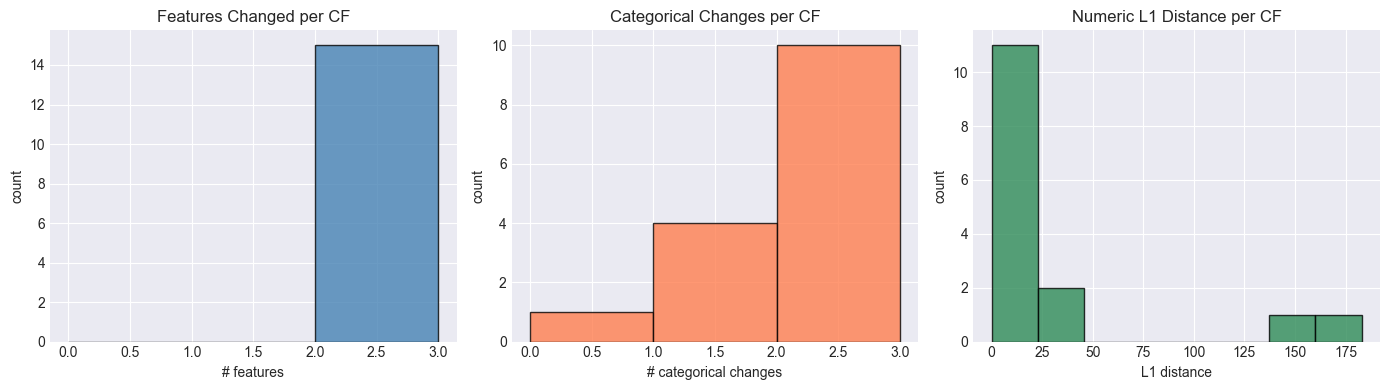


CF CHANGE DISTRIBUTION SUMMARY
             metric  mean  p50    p90
   features_changed  2.00  2.0   2.00
categorical_changes  1.60  2.0   2.00
         numeric_l1 26.54  0.0 103.06


In [16]:
# Distributions of counterfactual changes
if cf_quality:
    change_counts = cf_quality["change_counts"]
    cat_change_counts = cf_quality["cat_change_counts"]
    l1_dists = cf_quality["l1_dists"]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    if change_counts:
        bins = range(0, max(change_counts) + 2)
        axes[0].hist(change_counts, bins=bins, color="steelblue", alpha=0.8, edgecolor="black")
        axes[0].set_title("Features Changed per CF")
        axes[0].set_xlabel("# features")
        axes[0].set_ylabel("count")

    if cat_change_counts:
        bins = range(0, max(cat_change_counts) + 2)
        axes[1].hist(cat_change_counts, bins=bins, color="coral", alpha=0.8, edgecolor="black")
        axes[1].set_title("Categorical Changes per CF")
        axes[1].set_xlabel("# categorical changes")
        axes[1].set_ylabel("count")

    if l1_dists:
        axes[2].hist(l1_dists, bins=8, color="seagreen", alpha=0.8, edgecolor="black")
        axes[2].set_title("Numeric L1 Distance per CF")
        axes[2].set_xlabel("L1 distance")
        axes[2].set_ylabel("count")

    plt.tight_layout()
    plt.show()

    # Summary table
    def _summary(vals):
        if not vals:
            return {"mean": None, "p50": None, "p90": None}
        arr = np.array(vals, dtype=float)
        return {
            "mean": float(np.mean(arr)),
            "p50": float(np.percentile(arr, 50)),
            "p90": float(np.percentile(arr, 90)),
        }

    summary = pd.DataFrame({
        "metric": ["features_changed", "categorical_changes", "numeric_l1"],
        "mean": [
            _summary(change_counts)["mean"],
            _summary(cat_change_counts)["mean"],
            _summary(l1_dists)["mean"],
        ],
        "p50": [
            _summary(change_counts)["p50"],
            _summary(cat_change_counts)["p50"],
            _summary(l1_dists)["p50"],
        ],
        "p90": [
            _summary(change_counts)["p90"],
            _summary(cat_change_counts)["p90"],
            _summary(l1_dists)["p90"],
        ],
    })

    print("\nCF CHANGE DISTRIBUTION SUMMARY")
    print(summary.to_string(index=False))


## 7. Analyze Feature Changes

In [17]:
# Analyze which features change most frequently across all counterfactuals
def analyze_feature_changes(results, feature_cols):
    """Identify which features change in counterfactuals"""
    feature_changes = {feat: 0 for feat in feature_cols}
    total_cfs = 0

    for result in results:
        query = result["query"]
        cf_df = result["counterfactuals"]

        for feat in feature_cols:
            if feat in cf_df.columns and feat in query.columns:
                original_value = query[feat].values[0]
                cf_values = cf_df[feat].values

                if pd.api.types.is_numeric_dtype(cf_df[feat]):
                    changed = np.sum(~np.isclose(cf_values, original_value, rtol=0.01))
                else:
                    changed = np.sum(cf_values != original_value)

                feature_changes[feat] += changed

        total_cfs += len(cf_df)

    if total_cfs == 0:
        changes_df = pd.DataFrame({"feature": feature_cols, "change_count": 0, "change_pct": 0.0})
        return changes_df, total_cfs

    changes_df = pd.DataFrame([
        {"feature": k, "change_count": v, "change_pct": v/total_cfs*100}
        for k, v in feature_changes.items()
    ]).sort_values("change_count", ascending=False)

    return changes_df, total_cfs

changes_df, total_cfs = analyze_feature_changes(counterfactual_results, feature_cols)

print(f"\nFeature Change Analysis ({total_cfs} counterfactuals analyzed)")
print("="*60)
if total_cfs == 0:
    print("No counterfactuals generated; skipping change analysis.")
else:
    print(changes_df[changes_df["change_count"] > 0].head(15).to_string(index=False))



Feature Change Analysis (15 counterfactuals analyzed)
                  feature  change_count  change_pct
             deposit_type            12   80.000000
     distribution_channel             6   40.000000
                     meal             5   33.333333
                      adr             4   26.666667
total_of_special_requests             2   13.333333
           market_segment             1    6.666667


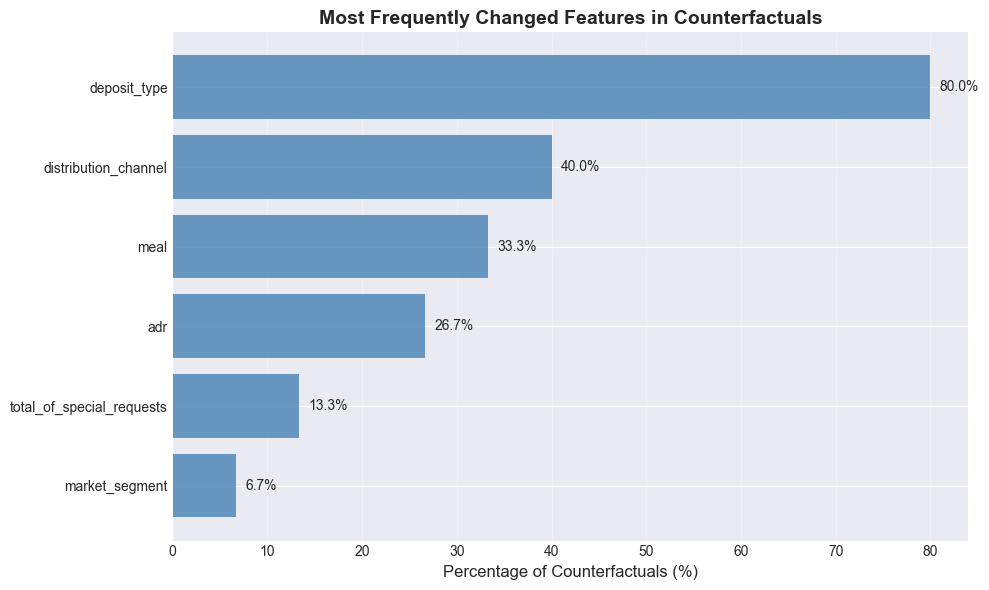

In [18]:
# Visualize most frequently changed features
top_features = changes_df[changes_df['change_count'] > 0].head(10)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(top_features)), top_features['change_pct'], color='steelblue', alpha=0.8)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'])
ax.set_xlabel('Percentage of Counterfactuals (%)', fontsize=12)
ax.set_title('Most Frequently Changed Features in Counterfactuals', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, (idx, row) in enumerate(top_features.iterrows()):
    ax.text(row['change_pct'] + 1, i, f"{row['change_pct']:.1f}%", 
            va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 8. Detailed Example Analysis

In [19]:
# Detailed analysis of first example
if len(counterfactual_results) > 0:
    example = counterfactual_results[0]
    
    print("="*70)
    print("DETAILED COUNTERFACTUAL EXAMPLE")
    print("="*70)
    
    print(f"\nOriginal Booking (Predicted as CANCELED with {example['original_prob']:.1%} probability):")
    print("-"*70)
    
    # Show key original features
    query = example['query']
    key_features = ['hotel', 'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 
                    'adults', 'meal', 'market_segment', 'deposit_type', 'adr', 'total_of_special_requests']
    
    for feat in key_features:
        if feat in query.columns:
            print(f"  {feat}: {query[feat].values[0]}")
    
    print("\n" + "="*70)
    print("COUNTERFACTUAL RECOMMENDATIONS (Changes needed to prevent cancellation):")
    print("="*70)
    
    # Show counterfactuals with only changed features
    cf_df = example['counterfactuals']
    
    for i, (idx, row) in enumerate(cf_df.iterrows()):
        print(f"\nCounterfactual #{i+1}:")
        print("-"*70)
        
        changes = []
        for feat in feature_cols:
            if feat in query.columns and feat in cf_df.columns:
                orig = query[feat].values[0]
                new = row[feat]
                
                # Check if changed
                if pd.api.types.is_numeric_dtype(query[feat]):
                    if not np.isclose(orig, new, rtol=0.01):
                        changes.append((feat, orig, new))
                else:
                    if orig != new:
                        changes.append((feat, orig, new))
        
        if changes:
            for feat, orig, new in changes:
                if isinstance(orig, float):
                    print(f"  {feat}: {orig:.2f} â†’ {new:.2f} (change: {new-orig:+.2f})")
                else:
                    print(f"  {feat}: {orig} â†’ {new}")
        else:
            print("  [No significant changes detected]")

DETAILED COUNTERFACTUAL EXAMPLE

Original Booking (Predicted as CANCELED with 98.9% probability):
----------------------------------------------------------------------
  hotel: City Hotel
  lead_time: 152
  stays_in_weekend_nights: 2
  stays_in_week_nights: 2
  adults: 1
  meal: BB
  market_segment: Offline TA/TO
  deposit_type: Non Refund
  adr: 95.0
  total_of_special_requests: 0

COUNTERFACTUAL RECOMMENDATIONS (Changes needed to prevent cancellation):

Counterfactual #1:
----------------------------------------------------------------------
  deposit_type: Non Refund â†’ No Deposit
  adr: 95.00 â†’ 65.30 (change: -29.70)

Counterfactual #2:
----------------------------------------------------------------------
  meal: BB â†’ Undefined
  deposit_type: Non Refund â†’ Refundable

Counterfactual #3:
----------------------------------------------------------------------
  deposit_type: Non Refund â†’ No Deposit
  adr: 95.00 â†’ 59.80 (change: -35.20)


## 9. Actionable Insights

In [20]:
# Extract actionable insights from counterfactual analysis
print("="*70)
print("ACTIONABLE INSIGHTS TO REDUCE CANCELLATIONS")
print("="*70)

# Top changed features
top_changed = changes_df[changes_df['change_count'] > 0].head(5)

print("\n1. MOST IMPACTFUL FEATURES FOR PREVENTING CANCELLATIONS:")
print("-"*70)
for idx, row in top_changed.iterrows():
    print(f"   â€¢ {row['feature']}: Changed in {row['change_pct']:.1f}% of counterfactuals")

print("\n2. STRATEGIC RECOMMENDATIONS:")
print("-"*70)
print("   â€¢ Focus on modifying the top features to reduce cancellation risk")
print("   â€¢ Consider offering incentives related to these features")
print("   â€¢ Develop targeted retention strategies based on these insights")

print("\n3. SPECIFIC INTERVENTIONS (based on common patterns):")
print("-"*70)

# Analyze specific feature changes
common_changes = {
    'deposit_type': 'Require or waive deposits strategically',
    'lead_time': 'Target bookings with specific advance booking windows',
    'market_segment': 'Focus on lower-risk market segments',
    'total_of_special_requests': 'Encourage special requests to increase engagement',
    'adr': 'Consider dynamic pricing adjustments',
    'assigned_room_type': 'Match room assignments to reservations',
    'distribution_channel': 'Optimize booking channels',
    'meal': 'Offer attractive meal packages'
}

for feat in top_changed['feature']:
    if feat in common_changes:
        print(f"   â€¢ {feat.upper()}: {common_changes[feat]}")

print("\n" + "="*70)

ACTIONABLE INSIGHTS TO REDUCE CANCELLATIONS

1. MOST IMPACTFUL FEATURES FOR PREVENTING CANCELLATIONS:
----------------------------------------------------------------------
   â€¢ deposit_type: Changed in 80.0% of counterfactuals
   â€¢ distribution_channel: Changed in 40.0% of counterfactuals
   â€¢ meal: Changed in 33.3% of counterfactuals
   â€¢ adr: Changed in 26.7% of counterfactuals
   â€¢ total_of_special_requests: Changed in 13.3% of counterfactuals

2. STRATEGIC RECOMMENDATIONS:
----------------------------------------------------------------------
   â€¢ Focus on modifying the top features to reduce cancellation risk
   â€¢ Consider offering incentives related to these features
   â€¢ Develop targeted retention strategies based on these insights

3. SPECIFIC INTERVENTIONS (based on common patterns):
----------------------------------------------------------------------
   â€¢ DEPOSIT_TYPE: Require or waive deposits strategically
   â€¢ DISTRIBUTION_CHANNEL: Optimize booking c

## 10. Visualize Example Counterfactual

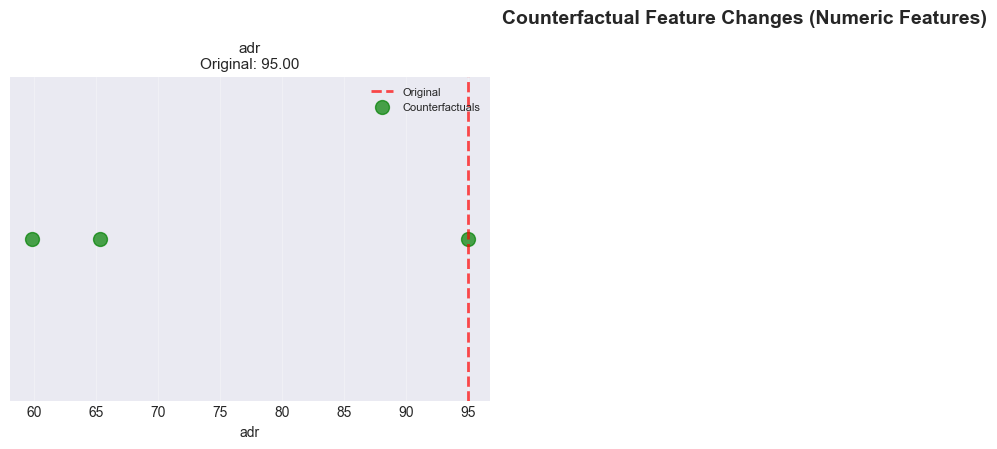

In [21]:
# Create a comprehensive visualization for one example
if len(counterfactual_results) > 0:
    example = counterfactual_results[0]
    query = example['query']
    cf_df = example['counterfactuals']
    
    # Identify all changed features
    changed_features = []
    for feat in feature_cols:
        if feat in query.columns and feat in cf_df.columns:
            orig = query[feat].values[0]
            cf_vals = cf_df[feat].values
            
            if pd.api.types.is_numeric_dtype(cf_df[feat]):
                if np.any(~np.isclose(cf_vals, orig, rtol=0.01)):
                    changed_features.append(feat)
            else:
                if np.any(cf_vals != orig):
                    changed_features.append(feat)
    
    # Visualize numeric feature changes
    numeric_changed = [f for f in changed_features if pd.api.types.is_numeric_dtype(query[f])]
    
    if len(numeric_changed) > 0:
        n_features = min(6, len(numeric_changed))
        fig, axes = plt.subplots(2, 3, figsize=(15, 8))
        axes = axes.ravel()
        
        for i, feat in enumerate(numeric_changed[:n_features]):
            orig_val = query[feat].values[0]
            cf_vals = cf_df[feat].values
            
            axes[i].axvline(orig_val, color='red', linestyle='--', linewidth=2, label='Original', alpha=0.7)
            axes[i].scatter(cf_vals, [1]*len(cf_vals), s=100, alpha=0.7, color='green', label='Counterfactuals')
            axes[i].set_xlabel(feat, fontsize=10)
            axes[i].set_yticks([])
            axes[i].set_title(f'{feat}\nOriginal: {orig_val:.2f}', fontsize=11)
            axes[i].legend(loc='upper right', fontsize=8)
            axes[i].grid(alpha=0.3)
        
        # Hide unused subplots
        for i in range(n_features, 6):
            axes[i].set_visible(False)
        
        plt.suptitle('Counterfactual Feature Changes (Numeric Features)', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

## 11. Save Results

In [22]:
# Save counterfactual analysis results
reports_dir = Path('../reports')
reports_dir.mkdir(exist_ok=True)

# Save feature change analysis
changes_df.to_csv(reports_dir / 'counterfactual_feature_changes.csv', index=False)
print(f"âœ“ Feature changes saved to: {reports_dir / 'counterfactual_feature_changes.csv'}")

# Save example counterfactuals
if len(counterfactual_results) > 0:
    example_cf = counterfactual_results[0]['counterfactuals']
    example_cf.to_csv(reports_dir / 'example_counterfactuals.csv', index=False)
    print(f"âœ“ Example counterfactuals saved to: {reports_dir / 'example_counterfactuals.csv'}")

# Save insights summary
insights_text = f"""# Counterfactual Explanation Insights

**Analysis Date**: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
**Model**: {metadata['model_name']}
**Samples Analyzed**: {len(counterfactual_results)}
**Total Counterfactuals Generated**: {total_cfs}

## Top 5 Most Impactful Features

"""

for idx, row in top_changed.iterrows():
    insights_text += f"{idx+1}. **{row['feature']}**: Changed in {row['change_pct']:.1f}% of counterfactuals\n"

insights_text += """
## Key Recommendations

1. **Priority Actions**: Focus interventions on the top 5 features identified above
2. **Strategic Targeting**: Use counterfactual insights to identify at-risk bookings early
3. **Personalized Interventions**: Apply feature-specific strategies to individual bookings
4. **Continuous Monitoring**: Track effectiveness of interventions based on feature changes

## Implementation Strategy

- Develop automated alerts for high-risk bookings
- Create targeted offers based on counterfactual recommendations
- Test interventions on subset of bookings and measure impact
- Refine strategies based on observed cancellation rate changes
"""

with open(reports_dir / 'counterfactual_insights.md', 'w') as f:
    f.write(insights_text)

print(f"âœ“ Insights summary saved to: {reports_dir / 'counterfactual_insights.md'}")

âœ“ Feature changes saved to: ..\reports\counterfactual_feature_changes.csv
âœ“ Example counterfactuals saved to: ..\reports\example_counterfactuals.csv
âœ“ Insights summary saved to: ..\reports\counterfactual_insights.md


## Summary

**DiCE Counterfactual Explanations completed successfully:**

1. âœ“ Loaded trained XGBoost classification model from Notebook 01
2. âœ“ Identified high-risk bookings predicted as cancellations
3. âœ“ Generated diverse counterfactual explanations using DiCE
4. âœ“ Analyzed which features need to change to prevent cancellations
5. âœ“ Identified most impactful features across multiple examples
6. âœ“ Provided actionable business recommendations
7. âœ“ Visualized counterfactual changes
8. âœ“ Saved results and insights to `reports/`

**Key Findings:**
- Counterfactuals reveal minimal changes needed to flip predictions
- Most impactful features identified for targeted interventions
- Specific, actionable recommendations generated for each booking
- Insights can guide hotel policies and customer retention strategies

**Business Value:**
- **Proactive Intervention**: Identify at-risk bookings before cancellation
- **Personalized Retention**: Apply specific interventions per booking
- **Strategic Planning**: Focus resources on most impactful features
- **Measurable Impact**: Track effectiveness of feature-based interventions

---

**All 5 notebooks completed! Full analytics pipeline ready for deployment.**